# Import libraries

In [7]:
import pypsa
import yaml
import pandas as pd
import geopandas as gpd
#import geoviews as gv
#import hvplot.pandas 
import numpy as np
import scipy as sp
import networkx as nx

# plotting stuff
import matplotlib.pyplot as plt
import cartopy

# data exploration
import xarray as xr
import cartopy.crs as ccrs


# Load data sets

In [8]:
# Load profile file from PyPSA-BO (build_renewable_profiles) and shapefile from MSR for costs and capacity caps (3.preescreened) and profiles (2.profile_generator)

pypsa_resources_path = r"C:\Users\Carlos\Desktop\PyPSA-BO\pypsa-earth\resources\renewable_profiles\profile_onwind_old.nc" 
MSR_shapes_path = r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia\Wind_prescreen.geojson"
MSR_profiles_path = r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\2. Profile Generator\Output_Bolivia\Results_UTC_Profiles\Bolivia\Bolivia wind 100m BiasCorrected ResourceProfiles.csv"

resources = xr.open_dataset(pypsa_resources_path)
shapes = gpd.read_file(MSR_shapes_path)
profiles = pd.read_csv(MSR_profiles_path)

# Explore csv (profles)

In [9]:
profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Columns: 8783 entries, MSR_ID to H8760
dtypes: float64(8779), int64(2), object(2)
memory usage: 102.5+ MB


In [10]:
profiles.columns

Index(['MSR_ID', 'AreakM2', 'CapacityMW', 'RoadDist', 'T_Dist_gf', 'D_Dist_gf',
       'TD_Dist_gf', 'SubstnDist', 'Load_dst', 'City_name',
       ...
       'H8751', 'H8752', 'H8753', 'H8754', 'H8755', 'H8756', 'H8757', 'H8758',
       'H8759', 'H8760'],
      dtype='object', length=8783)

In [11]:
profiles.shape

(1530, 8783)

In [12]:
profiles.head()

,MSR_ID,AreakM2,CapacityMW,RoadDist,T_Dist_gf,D_Dist_gf,TD_Dist_gf,SubstnDist,Load_dst,City_name,...,H8751,H8752,H8753,H8754,H8755,H8756,H8757,H8758,H8759,H8760
0,0,152.806260,449.250405,1.201183,6.791024,2.393051,2.393051,34.994978,21.379872,Montero,...,5.246,5.509,5.987,7.061,7.429,8.185,7.853,6.629,7.216,7.331
1,1,209.618699,616.278976,1.244803,3.597729,2.410556,2.410556,19.970997,15.999640,Santa Cruz1,...,4.176,4.495,5.088,6.141,7.503,7.752,7.702,6.646,6.512,7.572
2,2,22.950870,67.475558,0.711849,11.408714,0.888841,0.888841,15.603627,10.721693,Santa Cruz1,...,4.437,4.776,5.408,6.528,7.973,8.236,8.183,7.064,6.922,8.045
3,3,278.516488,818.838475,0.608752,8.425069,1.252322,1.252322,30.386299,24.486972,Montero,...,5.255,5.519,5.997,7.073,7.443,8.200,7.867,6.641,7.229,7.345
4,4,252.448276,742.197930,0.649362,2.751796,2.260233,2.260233,11.733223,11.284314,Santa Cruz1,...,4.219,4.541,5.141,6.204,7.580,7.831,7.780,6.714,6.579,7.649


In [13]:
print("SHAPE")
print(profiles.shape)

print("\nCOLUMNS")
print(profiles.dtypes)

print("\nHEAD")
print(profiles.head(3))


SHAPE
(1530, 8783)

COLUMNS
MSR_ID          int64
AreakM2       float64
CapacityMW    float64
RoadDist      float64
T_Dist_gf     float64
               ...   
H8756         float64
H8757         float64
H8758         float64
H8759         float64
H8760         float64
Length: 8783, dtype: object

HEAD
   MSR_ID     AreakM2  CapacityMW  RoadDist  T_Dist_gf  D_Dist_gf  TD_Dist_gf  \
0       0  152.806260  449.250405  1.201183   6.791024   2.393051    2.393051   
1       1  209.618699  616.278976  1.244803   3.597729   2.410556    2.410556   
2       2   22.950870   67.475558  0.711849  11.408714   0.888841    0.888841   

   SubstnDist   Load_dst    City_name  ...  H8751  H8752  H8753  H8754  H8755  \
0   34.994978  21.379872      Montero  ...  5.246  5.509  5.987  7.061  7.429   
1   19.970997  15.999640  Santa Cruz1  ...  4.176  4.495  5.088  6.141  7.503   
2   15.603627  10.721693  Santa Cruz1  ...  4.437  4.776  5.408  6.528  7.973   

   H8756  H8757  H8758  H8759  H8760  
0  8.18

# Explore geojson (shapes)

In [14]:
shapes.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID         1530 non-null   int64   
 1   AreakM2     1530 non-null   float64 
 2   CapacityMW  1530 non-null   float64 
 3   RoadDist    1530 non-null   float64 
 4   T_Dist_gf   1530 non-null   float64 
 5   D_Dist_gf   1530 non-null   float64 
 6   TD_Dist_gf  1530 non-null   float64 
 7   SubstnDist  1530 non-null   float64 
 8   Load_dst    1530 non-null   float64 
 9   City_name   1530 non-null   object  
 10  City_Pop    1530 non-null   int64   
 11  CtLst100kM  1530 non-null   object  
 12  CtCnt100kM  1530 non-null   int64   
 13  PopIn100kM  1530 non-null   int64   
 14  Elev_mean   1530 non-null   float64 
 15  Elev_max    1530 non-null   int64   
 16  Elev_centr  1530 non-null   int64   
 17  CtryName    1530 non-null   object  
 18  MeanSpeed   1530 non-null   object  
 19

In [15]:
shapes.shape

(1530, 31)

In [16]:
shapes.head()
#shapes.crs

,FID,AreakM2,CapacityMW,RoadDist,T_Dist_gf,D_Dist_gf,TD_Dist_gf,SubstnDist,Load_dst,City_name,...,CF100m,Y_GWh100m,sLCOE-MWh,tLCOE-MWh,tCAPEX-kW,rLCOE-MWh,rCAPEX-kW,LCOE-MWh,trCAPEX-kW,geometry
0,0,152.806260,449.250405,1.201183,6.791024,2.393051,2.393051,34.994978,21.379872,Montero,...,44.935736,1768.416018,47.380638,2.160436,83.163732,0.292804,10.462067,49.833877,93.625799,"POLYGON ((-63.38956 -17.46986, -63.38647 -17.4..."
1,1,209.618699,616.278976,1.244803,3.597729,2.410556,2.410556,19.970997,15.999640,Santa Cruz1,...,46.473415,2508.915559,45.812941,2.003985,79.781074,0.293397,10.841983,48.110323,90.623057,"POLYGON ((-63.41391 -17.61098, -63.41082 -17.6..."
2,2,22.950870,67.475558,0.711849,11.408714,0.888841,0.888841,15.603627,10.721693,Santa Cruz1,...,43.952669,259.798023,41.734873,2.338671,88.055250,0.177404,6.200061,44.250948,94.255311,"POLYGON ((-63.32942 -17.87104, -63.33174 -17.8..."
3,3,278.516488,818.838475,0.608752,8.425069,1.252322,1.252322,30.386299,24.486972,Montero,...,45.037951,3230.583491,47.273106,2.200397,84.894676,0.148054,5.302104,49.621557,90.196780,"POLYGON ((-63.25947 -17.55403, -63.25893 -17.5..."
4,4,252.448276,742.197930,0.649362,2.751796,2.260233,2.260233,11.733223,11.284314,Santa Cruz1,...,41.020855,2667.034008,44.717719,2.244858,78.884977,0.173397,5.655814,47.135974,84.540791,"POLYGON ((-63.28986 -17.72242, -63.28932 -17.7..."


<AxesSubplot:>

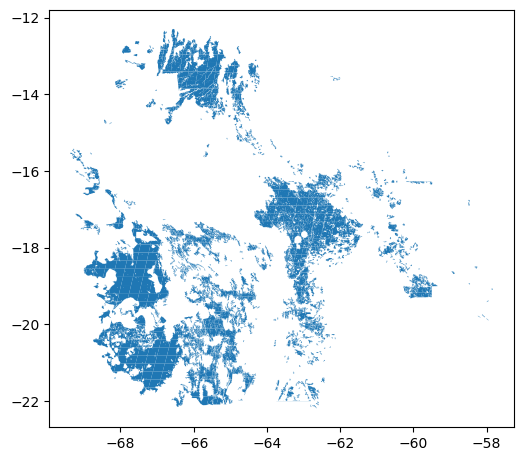

In [17]:
shapes.plot(figsize=(6,6)) #, edgecolor="black")

In [18]:
shapes.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [19]:
print("SHAPE")
print(shapes.shape)

print("\nCOLUMNS")
print(shapes.dtypes)

print("\nCRS")
print(shapes.crs)

print("\nGEOMETRY TYPES")
print(shapes.geometry.type.value_counts())

print("\nHEAD")
print(shapes.head(3)[["geometry", "LCOE-MWh"]])

SHAPE
(1530, 31)

COLUMNS
FID              int64
AreakM2        float64
CapacityMW     float64
RoadDist       float64
T_Dist_gf      float64
D_Dist_gf      float64
TD_Dist_gf     float64
SubstnDist     float64
Load_dst       float64
City_name       object
City_Pop         int64
CtLst100kM      object
CtCnt100kM       int64
PopIn100kM       int64
Elev_mean      float64
Elev_max         int64
Elev_centr       int64
CtryName        object
MeanSpeed       object
IEC_Class       object
ERA_WSpeed     float64
CF100m         float64
Y_GWh100m      float64
sLCOE-MWh      float64
tLCOE-MWh      float64
tCAPEX-kW      float64
rLCOE-MWh      float64
rCAPEX-kW      float64
LCOE-MWh       float64
trCAPEX-kW     float64
geometry      geometry
dtype: object

CRS
EPSG:4326

GEOMETRY TYPES
Polygon    1530
Name: count, dtype: int64

HEAD
                                            geometry   LCOE-MWh
0  POLYGON ((-63.38956 -17.46986, -63.38647 -17.4...  49.833877
1  POLYGON ((-63.41391 -17.61098, -63.41

# Explore xarray (resources)

In [20]:
resources

<xarray.Dataset>
Dimensions:           (time: 8760, bus: 122, y: 46, x: 43)
Coordinates:
  * time              (time) datetime64[ns] 2013-01-01 ... 2013-12-31T23:00:00
  * bus               (bus) <U3 '0' '1' '4' '6' '8' ... '162' '163' '164' '165'
  * y                 (y) float64 -23.1 -22.8 -22.5 -22.2 ... -10.2 -9.9 -9.6
  * x                 (x) float64 -69.9 -69.6 -69.3 -69.0 ... -57.9 -57.6 -57.3
Data variables:
    profile           (time, bus) float64 ...
    weight            (bus) float64 ...
    p_nom_max         (bus) float64 ...
    potential         (y, x) float64 ...
    average_distance  (bus) float64 ...

In [21]:
resources.data_vars

Data variables:
    profile           (time, bus) float64 ...
    weight            (bus) float64 ...
    p_nom_max         (bus) float64 ...
    potential         (y, x) float64 ...
    average_distance  (bus) float64 ...

In [22]:
resources["potential"].values[:2]

array([[  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,  38.37790493,
         80.76741382,  83.33561505,   6.8080904 ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        , 296.77285148, 324

In [23]:
resources["average_distance"].values

array([ 30.20308933,  20.45176602,  32.19423982,  15.62823751,
        13.25483026,  21.2212949 ,  40.93390394,  32.75805465,
        27.42925046,  42.31817564,  89.90508299,  46.35537835,
        44.20356558,  16.84261108,  71.63892747,  92.71774679,
        19.54974039,  22.18275488,  34.08310799, 160.20678487,
        21.63184201,  20.0723637 ,  54.13741898,  26.47570582,
        88.78660149,  36.87314433,  74.95921832,  19.89827241,
        23.88822144,  22.53312083,  16.99803441,  27.62902217,
        19.55115657,  21.48621245,  24.81140252,  22.02416156,
        44.42084265,  26.26548591,  20.23460365,  35.92476513,
        20.86905562,  29.91513388,  28.3588295 ,  43.48995303,
        37.3647594 ,  65.00620049,  23.68045581,  17.24141988,
        51.75844233,  15.83088858,   1.15168394,  21.65029203,
        74.74566547,  28.30452663,  62.2839164 ,  26.35636302,
        32.75374256,  35.27957744,  18.60713664,  60.97464697,
        18.72335046,  16.93470694,  52.96550846,  10.68

In [24]:
resources["time"].to_pandas().value_counts()

2013-01-01 00:00:00    1
2013-09-01 10:00:00    1
2013-09-01 04:00:00    1
2013-09-01 05:00:00    1
2013-09-01 06:00:00    1
                      ..
2013-05-02 10:00:00    1
2013-05-02 09:00:00    1
2013-05-02 08:00:00    1
2013-05-02 07:00:00    1
2013-12-31 23:00:00    1
Name: count, Length: 8760, dtype: int64

In [25]:
resources["profile"].values


array([[0.        , 0.        , 0.        , ..., 0.        , 0.38982944,
        0.        ],
       [0.        , 0.03030433, 0.        , ..., 0.        , 0.40737533,
        0.        ],
       [0.        , 0.06219321, 0.        , ..., 0.        , 0.4115003 ,
        0.        ],
       ...,
       [0.        , 0.        , 0.01628913, ..., 0.        , 0.9729582 ,
        0.        ],
       [0.        , 0.02152118, 0.01502085, ..., 0.        , 0.87710443,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.74873333,
        0.        ]])

In [26]:
print(resources)

print("\nDIMS")
print(resources.dims)

print("\nDATA VARS")
for v in resources.data_vars:
    print(v, resources[v].dims, resources[v].dtype)

print("\nCOORDS")
for c in resources.coords:
    print(c, resources[c].dims, resources[c].dtype)

print("\nATTRIBUTES")
print(resources.attrs)

print("\nVAR ATTRIBUTES (wind)")
print(resources["profile"].attrs)

<xarray.Dataset>
Dimensions:           (time: 8760, bus: 122, y: 46, x: 43)
Coordinates:
  * time              (time) datetime64[ns] 2013-01-01 ... 2013-12-31T23:00:00
  * bus               (bus) <U3 '0' '1' '4' '6' '8' ... '162' '163' '164' '165'
  * y                 (y) float64 -23.1 -22.8 -22.5 -22.2 ... -10.2 -9.9 -9.6
  * x                 (x) float64 -69.9 -69.6 -69.3 -69.0 ... -57.9 -57.6 -57.3
Data variables:
    profile           (time, bus) float64 0.0 0.0 0.0 0.1551 ... 0.0 0.7487 0.0
    weight            (bus) float64 ...
    p_nom_max         (bus) float64 ...
    potential         (y, x) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    average_distance  (bus) float64 30.2 20.45 32.19 15.63 ... 53.37 16.8 40.82

DIMS
Frozen({'time': 8760, 'bus': 122, 'y': 46, 'x': 43})

DATA VARS
profile ('time', 'bus') float64
weight ('bus',) float64
p_nom_max ('bus',) float64
potential ('y', 'x') float64
average_distance ('bus',) float64

COORDS
time ('time',) datetime64[ns]
bus

# Data structure

In [27]:
# === CSV STRUCTURE ===

# SHAPE
# (1530, 8783)

# COLUMNS
# MSR_ID          int64
# AreakM2       float64
# CapacityMW    float64
# RoadDist      float64
# T_Dist_gf     float64
#                ...   
# H8756         float64
# H8757         float64
# H8758         float64
# H8759         float64
# H8760         float64
# Length: 8783, dtype: object

# HEAD
#    MSR_ID     AreakM2  CapacityMW  RoadDist  T_Dist_gf  D_Dist_gf  TD_Dist_gf  \
# 0       0  152.806260  449.250405  1.201183   6.791024   2.393051    2.393051   
# 1       1  209.618699  616.278976  1.244803   3.597729   2.410556    2.410556   
# 2       2   22.950870   67.475558  0.711849  11.408714   0.888841    0.888841   

#    SubstnDist   Load_dst    City_name  ...  H8751  H8752  H8753  H8754  H8755  \
# 0   34.994978  21.379872      Montero  ...  5.246  5.509  5.987  7.061  7.429   
# ...
# 1  7.752  7.702  6.646  6.512  7.572  
# 2  8.236  8.183  7.064  6.922  8.045  

# [3 rows x 8783 columns]

# For the profile sample, each value is defined in a column corresponding to a particular hour of the year ("H1, H2, ... H8755, ..., H8760")



# === GEOJSON STRUCTURE ===

# SHAPE
# (1530, 31)

# COLUMNS
# FID              int64
# AreakM2        float64
# CapacityMW     float64
# RoadDist       float64
# T_Dist_gf      float64
# D_Dist_gf      float64
# TD_Dist_gf     float64
# SubstnDist     float64
# Load_dst       float64
# City_name       object
# City_Pop         int64
# CtLst100kM      object
# CtCnt100kM       int64
# PopIn100kM       int64
# Elev_mean      float64
# Elev_max         int64
# Elev_centr       int64
# CtryName        object
# MeanSpeed       object
# IEC_Class       object
# ERA_WSpeed     float64
# ...
#                                             geometry   LCOE-MWh
# 0  POLYGON ((-63.38956 -17.46986, -63.38647 -17.4...  49.833877
# 1  POLYGON ((-63.41391 -17.61098, -63.41082 -17.6...  48.110323
# 2  POLYGON ((-63.32942 -17.87104, -63.33174 -17.8...  44.250948


# === PYPSA NC STRUCTURE ===


# <xarray.Dataset>
# Dimensions:           (time: 8760, bus: 122, y: 46, x: 43)
# Coordinates:
#   * time              (time) datetime64[ns] 2013-01-01 ... 2013-12-31T23:00:00
#   * bus               (bus) <U3 '0' '1' '4' '6' '8' ... '162' '163' '164' '165'
#   * y                 (y) float64 -23.1 -22.8 -22.5 -22.2 ... -10.2 -9.9 -9.6
#   * x                 (x) float64 -69.9 -69.6 -69.3 -69.0 ... -57.9 -57.6 -57.3
# Data variables:
#     profile           (time, bus) float64 0.0 0.0 0.0 0.3723 ... 0.0 1.797 0.0
#     weight            (bus) float64 ...
#     p_nom_max         (bus) float64 ...
#     potential         (y, x) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
#     average_distance  (bus) float64 30.2 20.45 32.19 15.63 ... 53.37 16.8 40.82

# DIMS
# Frozen({'time': 8760, 'bus': 122, 'y': 46, 'x': 43})

# DATA VARS
# profile ('time', 'bus') float64
# weight ('bus',) float64
# p_nom_max ('bus',) float64
# potential ('y', 'x') float64
# average_distance ('bus',) float64

# COORDS
# ...
# {}

# VAR ATTRIBUTES (wind)
# {}


# Coupling MSR outputs

In [28]:
#reorganizing profiles from MSR (script 2)

id_cols = [
    "MSR_ID", "AreakM2", "CapacityMW", "RoadDist",
    "T_Dist_gf", "D_Dist_gf", "TD_Dist_gf",
    "SubstnDist", "Load_dst", "City_name"
]

profile_cols = [c for c in profiles.columns if c.startswith("H")]

df_long = (
    profiles[["MSR_ID"] + profile_cols]
    .melt(id_vars="MSR_ID", var_name="hour", value_name="profile")
)

df_long["time"] = df_long["hour"].str.replace("H", "").astype(int) - 1

In [29]:
#convert to xarray
xr_msr = (
    df_long
    .set_index(["time", "MSR_ID"])
    .to_xarray()
)

xr_msr

<xarray.Dataset>
Dimensions:  (time: 8760, MSR_ID: 1530)
Coordinates:
  * time     (time) int32 0 1 2 3 4 5 6 7 ... 8753 8754 8755 8756 8757 8758 8759
  * MSR_ID   (MSR_ID) int64 0 1 2 3 4 5 6 ... 1523 1524 1525 1526 1527 1528 1529
Data variables:
    hour     (time, MSR_ID) object 'H1' 'H1' 'H1' ... 'H8760' 'H8760' 'H8760'
    profile  (time, MSR_ID) float64 11.43 11.56 12.26 11.45 ... 3.468 1.42 0.625

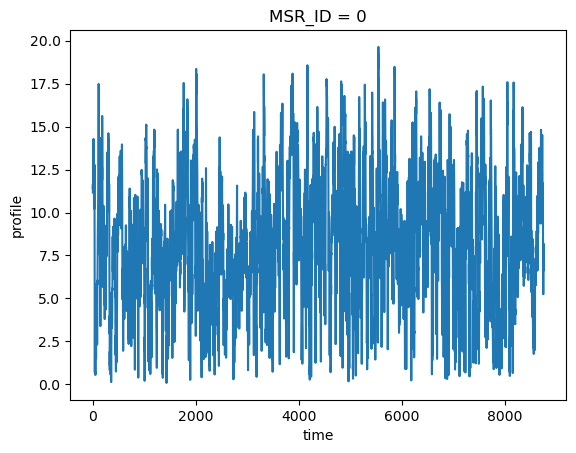

In [30]:
xr_msr.profile.isel(MSR_ID=0).plot()

In [31]:
#Add parameters from the shapes file into the new xarray 
xr_msr["p_nom_max"] = ("MSR_ID", shapes.set_index("FID")["CapacityMW"])
xr_msr["CAPEX"] = ("MSR_ID", shapes.set_index("FID")["trCAPEX-kW"])
xr_msr["AreakM2"] = ("MSR_ID", shapes.set_index("FID")["AreakM2"])

xr_msr["weight"] = ("MSR_ID", np.ones(len(xr_msr.MSR_ID)))

xr_msr

<xarray.Dataset>
Dimensions:    (time: 8760, MSR_ID: 1530)
Coordinates:
  * time       (time) int32 0 1 2 3 4 5 6 ... 8753 8754 8755 8756 8757 8758 8759
  * MSR_ID     (MSR_ID) int64 0 1 2 3 4 5 6 ... 1524 1525 1526 1527 1528 1529
Data variables:
    hour       (time, MSR_ID) object 'H1' 'H1' 'H1' ... 'H8760' 'H8760' 'H8760'
    profile    (time, MSR_ID) float64 11.43 11.56 12.26 ... 3.468 1.42 0.625
    p_nom_max  (MSR_ID) float64 449.3 616.3 67.48 ... 1.189e+03 23.38 74.65
    CAPEX      (MSR_ID) float64 93.63 90.62 94.26 90.2 ... 221.4 187.6 208.9
    AreakM2    (MSR_ID) float64 152.8 209.6 22.95 278.5 ... 404.4 7.951 25.39
    weight     (MSR_ID) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

In [32]:
#Check coordinated for each MSR
msr_coor = pd.DataFrame()

msr_coor["MSR_ID"] = shapes["FID"]
msr_coor["lon"] = shapes.geometry.centroid.x
msr_coor["lat"] = shapes.geometry.centroid.y

msr_coor = msr_coor.rename({"FID":"MSR_ID"})

msr_coor


C:\Users\Carlos\AppData\Local\Temp\ipykernel_13352\1693366268.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  msr_coor["lon"] = shapes.geometry.centroid.x
C:\Users\Carlos\AppData\Local\Temp\ipykernel_13352\1693366268.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  msr_coor["lat"] = shapes.geometry.centroid.y


,MSR_ID,lon,lat
0,0,-63.308417,-17.510699
1,1,-63.348067,-17.685777
2,2,-63.334089,-17.822617
3,3,-63.167522,-17.511240
4,4,-63.218541,-17.674052
...,...,...,...
1525,1525,-64.995948,-22.010512
1526,1526,-62.622829,-22.075490
1527,1527,-66.398832,-21.998082
1528,1528,-62.800651,-22.122785


In [33]:
#Add coordinates of each MSR
xr_msr = xr_msr.assign_coords(
    lat=("MSR_ID", msr_coor["lat"].values),
    lon=("MSR_ID", msr_coor["lon"].values),)
xr_msr

<xarray.Dataset>
Dimensions:    (time: 8760, MSR_ID: 1530)
Coordinates:
  * time       (time) int32 0 1 2 3 4 5 6 ... 8753 8754 8755 8756 8757 8758 8759
  * MSR_ID     (MSR_ID) int64 0 1 2 3 4 5 6 ... 1524 1525 1526 1527 1528 1529
    lat        (MSR_ID) float64 -17.51 -17.69 -17.82 ... -22.0 -22.12 -22.13
    lon        (MSR_ID) float64 -63.31 -63.35 -63.33 ... -66.4 -62.8 -62.7
Data variables:
    hour       (time, MSR_ID) object 'H1' 'H1' 'H1' ... 'H8760' 'H8760' 'H8760'
    profile    (time, MSR_ID) float64 11.43 11.56 12.26 ... 3.468 1.42 0.625
    p_nom_max  (MSR_ID) float64 449.3 616.3 67.48 ... 1.189e+03 23.38 74.65
    CAPEX      (MSR_ID) float64 93.63 90.62 94.26 90.2 ... 221.4 187.6 208.9
    AreakM2    (MSR_ID) float64 152.8 209.6 22.95 278.5 ... 404.4 7.951 25.39
    weight     (MSR_ID) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

In [34]:
xr_msr.to_netcdf("Cost-Supply\msr_profiles_pypsa_compatible.nc")

# Mapping PyPSA buses to MSR map

In [35]:
# Loading bus map from pypsa

n_base = pypsa.Network(r"C:\Users\Carlos\Desktop\PyPSA-BO\pypsa-earth\networks\base.nc")

buses = n_base.buses.loc[resources.bus.values] #.loc[resources.bus.values] -> this section makes the buses match only the ones available in resources, not all the ones available in all buses

gdf_resources = gpd.GeoDataFrame(
    buses,
    geometry=gpd.points_from_xy(buses.x, buses.y),
    crs="EPSG:4326"
)

gdf_resources#.plot()

c:\Users\Carlos\anaconda3\envs\pypsa-earth\lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\Carlos\anaconda3\envs\pypsa-earth\lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Users\Carlos\anaconda3\envs\pypsa-earth\lib\site-packages\pypsa\components.py:318: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatibl

,v_nom,symbol,under_construction,tag_substation,tag_area,lon,lat,country,substation_lv,x,...,substation_off,type,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,sub_network,geometry
Bus,,,,,,,,,,,,,,,,,,,,,
0,115.0,substation,False,transmission,0.0,-67.8342,-16.2877,BO,True,-67.8342,...,True,,AC,,1.0,0.0,inf,PQ,,POINT (-67.83420 -16.28770)
1,69.0,substation,False,transmission,0.0,-67.0666,-17.9689,BO,True,-67.0666,...,True,,AC,,1.0,0.0,inf,PQ,,POINT (-67.06660 -17.96890)
4,69.0,substation,False,transmission,0.0,-65.7977,-19.6051,BO,True,-65.7977,...,True,,AC,,1.0,0.0,inf,PQ,,POINT (-65.79770 -19.60510)
6,115.0,substation,False,transmission,0.0,-63.6326,-17.4214,BO,True,-63.6326,...,True,,AC,,1.0,0.0,inf,PQ,,POINT (-63.63260 -17.42140)
8,69.0,substation,False,transmission,0.0,-63.1863,-17.7498,BO,True,-63.1863,...,True,,AC,,1.0,0.0,inf,PQ,,POINT (-63.18630 -17.74980)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,115.0,substation,False,transmission,0.0,-67.3594,-20.5829,BO,True,-67.3594,...,True,,AC,,1.0,0.0,inf,PQ,,POINT (-67.35940 -20.58290)
162,69.0,substation,False,transmission,0.0,-66.1743,-20.0013,BO,True,-66.1743,...,True,,AC,,1.0,0.0,inf,PQ,,POINT (-66.17430 -20.00130)
163,115.0,substation,False,transmission,0.0,-65.2869,-17.6239,BO,True,-65.2869,...,True,,AC,,1.0,0.0,inf,PQ,,POINT (-65.28690 -17.62390)


<AxesSubplot:>

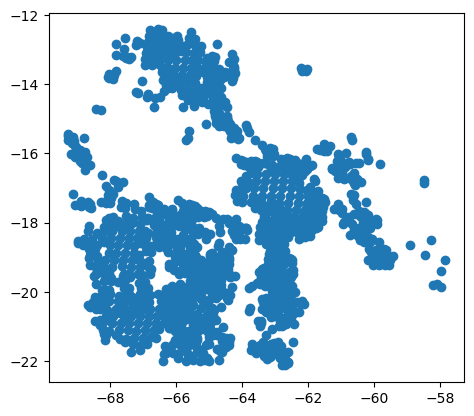

In [36]:
# creating MSR map from centroids
gdf_msr_pts = gpd.GeoDataFrame(
    msr_coor,
    geometry=gpd.points_from_xy(msr_coor.lon, msr_coor.lat),
    crs="EPSG:4326"
)

gdf_msr_pts.plot()

In [37]:
# reprojecting (for distances?)
gdf_msr_pts = gdf_msr_pts.to_crs(3857)
gdf_resources = gdf_resources.to_crs(3857)

In [38]:
#Assign a bus to each MSR
msr_to_bus = gpd.sjoin_nearest(
    gdf_msr_pts,
    gdf_resources[["geometry"]],
    how="left"
)

msr_to_bus = (
    msr_to_bus
    .reset_index(drop=True)
    .rename(columns={"index": "MSR_ID", "index_right": "bus"})
)

msr_to_bus

,MSR_ID,lon,lat,geometry,bus
0,0,-63.308417,-17.510699,POINT (-7047460.733 -1980355.340),40
1,1,-63.348067,-17.685777,POINT (-7051874.536 -2000801.830),40
2,2,-63.334089,-17.822617,POINT (-7050318.512 -2016796.576),83
3,3,-63.167522,-17.511240,POINT (-7031776.371 -1980418.501),37
4,4,-63.218541,-17.674052,POINT (-7037455.842 -1999431.975),101
...,...,...,...,...,...
1525,1525,-64.995948,-22.010512,POINT (-7235315.812 -2512787.373),109
1526,1526,-62.622829,-22.075490,POINT (-6971141.400 -2520591.157),92
1527,1527,-66.398832,-21.998082,POINT (-7391484.194 -2511294.965),150
1528,1528,-62.800651,-22.122785,POINT (-6990936.463 -2526273.495),92


In [39]:
#Check how many unique buses from pypsa include data from the MSR outputs
msr_to_bus["bus"].nunique()


87

In [40]:
#create data set of equivalence MSR-bus
bus_map = (
    msr_to_bus
    .set_index("MSR_ID")
    .loc[xr_msr.MSR_ID.values, "bus"]
    .astype(str)
)

#Add bus as coordinate in the xarray
xr_msr = xr_msr.assign_coords(
    bus=("MSR_ID", bus_map.values)
)

xr_msr

<xarray.Dataset>
Dimensions:    (time: 8760, MSR_ID: 1530)
Coordinates:
  * time       (time) int32 0 1 2 3 4 5 6 ... 8753 8754 8755 8756 8757 8758 8759
  * MSR_ID     (MSR_ID) int64 0 1 2 3 4 5 6 ... 1524 1525 1526 1527 1528 1529
    lat        (MSR_ID) float64 -17.51 -17.69 -17.82 ... -22.0 -22.12 -22.13
    lon        (MSR_ID) float64 -63.31 -63.35 -63.33 ... -66.4 -62.8 -62.7
    bus        (MSR_ID) object '40' '40' '83' '37' ... '92' '150' '92' '92'
Data variables:
    hour       (time, MSR_ID) object 'H1' 'H1' 'H1' ... 'H8760' 'H8760' 'H8760'
    profile    (time, MSR_ID) float64 11.43 11.56 12.26 ... 3.468 1.42 0.625
    p_nom_max  (MSR_ID) float64 449.3 616.3 67.48 ... 1.189e+03 23.38 74.65
    CAPEX      (MSR_ID) float64 93.63 90.62 94.26 90.2 ... 221.4 187.6 208.9
    AreakM2    (MSR_ID) float64 152.8 209.6 22.95 278.5 ... 404.4 7.951 25.39
    weight     (MSR_ID) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

# Aggregate weighted MSR profiles to each (PyPSA) bus 

In [41]:
#define weight and aggragate based on buses and numerator and denominator for weighted average
weights = xr_msr["AreakM2"]

num = (xr_msr["profile"] * weights).groupby("bus").sum(dim="MSR_ID")

den = weights.groupby("bus").sum(dim="MSR_ID")

xr_bus_profile = num / den
xr_bus_profile


<xarray.DataArray (time: 8760, bus: 87)>
array([[ 2.7278204 , 10.482     , 11.678     , ...,  6.88105766,
         3.185     ,  7.42638223],
       [ 7.91130686, 11.175     , 11.355     , ...,  8.67061954,
         7.698     ,  7.67603707],
       [ 5.33867605, 10.685     , 10.87      , ...,  8.6112636 ,
         3.467     ,  6.18548697],
       ...,
       [ 9.5340518 ,  6.114     ,  6.714     , ...,  8.45637938,
         8.207     ,  2.71864432],
       [ 7.9043421 ,  6.778     ,  6.579     , ...,  7.68207403,
         5.574     ,  1.79194861],
       [ 8.46646121,  6.342     ,  7.649     , ...,  7.35276777,
         6.221     ,  2.06707488]])
Coordinates:
  * time     (time) int32 0 1 2 3 4 5 6 7 ... 8753 8754 8755 8756 8757 8758 8759
  * bus      (bus) object '1' '100' '101' '102' '103' ... '94' '95' '96' '97'

In [42]:
xr_bus_profile.min().item(), xr_bus_profile.max().item()

(0.058, 20.417677811550192)

In [43]:
p_nom_bus = xr_msr["p_nom_max"].groupby("bus").sum(dim="MSR_ID")
p_nom_bus

<xarray.DataArray 'p_nom_max' (bus: 87)>
array([1.51541071e+03, 1.80769773e+03, 7.42197930e+02, 6.78487987e+03,
       1.17794437e+03, 1.25288031e+03, 1.15966974e+03, 2.83488424e+02,
       4.42443077e+03, 2.16187437e+03, 8.52087012e+02, 3.50660380e+01,
       6.58816471e+01, 3.01166286e+03, 1.93934671e+03, 2.61648430e+04,
       2.76756048e+03, 1.62425888e+04, 3.75358407e+03, 1.17148792e+04,
       6.16347603e+03, 7.65836197e+01, 2.86344971e+03, 1.37975119e+03,
       5.26664819e+03, 1.17418097e+03, 1.74657838e+04, 3.35089863e+03,
       2.07874540e+04, 1.57372571e+04, 1.37341982e+02, 1.31231991e+03,
       3.32607746e+04, 2.14840148e+04, 3.44218323e+02, 8.52174456e+03,
       2.19740973e+04, 2.33834572e+04, 2.39352274e+03, 1.44481596e+04,
       9.21802900e+02, 1.21509135e+03, 1.25575056e+03, 1.32210630e+04,
       1.93952381e+03, 2.25101383e+04, 1.08932735e+03, 4.17829173e+03,
       8.93136541e+03, 8.15009769e+03, 1.06100002e+04, 3.45790097e+02,
       2.26667002e+04, 2.81590911e+02, 6.13204056e+03, 1.47973177e+04,
       1.02080026e+03, 5.62750138e+02, 1.35376159e+03, 5.70349651e+03,
       4.29034303e+03, 1.80633711e+04, 7.50656094e+02, 2.00240359e+03,
       2.43511053e+03, 2.67369121e+03, 6.95299318e+02, 1.12401705e+03,
       2.75200720e+03, 2.64412094e+02, 1.67812244e+03, 1.21137222e+02,
       5.10051461e+01, 1.88267433e+03, 2.83627796e+03, 6.99195545e+02,
       9.93441142e+02, 7.49784584e+03, 6.67350535e+02, 4.05828289e+04,
       2.91685679e+02, 1.91720906e+03, 1.82263702e+03, 6.90499876e+03,
       9.08900635e+03, 4.54663060e+02, 2.17117218e+03])
Coordinates:
  * bus      (bus) object '1' '100' '101' '102' '103' ... '94' '95' '96' '97'

In [44]:
capex_bus = (
    (xr_msr["CAPEX"] * xr_msr["AreakM2"])
    .groupby("bus")
    .sum(dim="MSR_ID")
    / den
)

capex_bus

<xarray.DataArray (bus: 87)>
array([ 98.57216615, 120.98116609,  84.54079125, 144.2268345 ,
       105.11297708, 182.18072449, 137.98868418, 133.46042021,
       128.38352194, 140.37289866, 172.2006827 , 143.4192087 ,
       113.13392274, 110.73632331, 108.65904379, 250.52392305,
       103.51116171, 180.50648692, 126.27161219, 153.74921548,
       107.22777517,  83.55147407, 130.86294965, 118.26448022,
       106.17746345,  97.38458102, 280.5778746 , 122.44542304,
       263.49235058, 223.96297265, 130.87980797, 180.22049683,
       352.04832757, 178.32121245,  88.86158919, 183.09165127,
       224.94899707, 380.20255285, 193.24879731, 239.1522234 ,
       118.43764307, 112.46886278,  99.03837718, 137.14981382,
       165.17618839, 252.27176489, 136.3137042 , 116.77713833,
       258.98228834, 164.04116042, 160.84530372, 101.22609339,
       134.55939228, 209.5102893 , 127.93239818, 282.22126907,
        89.55554967, 130.02912294,  91.1523947 , 174.97709502,
       154.56947513, 259.53631118, 116.46486163, 138.29737687,
       106.19113897, 101.54205447, 116.28751238,  98.77483523,
       124.30488217, 128.57114572, 119.22552733,  91.25757727,
       163.0360614 , 129.52899389, 120.65195173,  93.49040107,
       103.33566981, 131.47274651,  95.71196035, 208.37925035,
       179.91876871, 137.83435936, 122.38347665, 151.56042966,
       164.24654132,  92.4806687 , 159.50573852])
Coordinates:
  * bus      (bus) object '1' '100' '101' '102' '103' ... '94' '95' '96' '97'

# Build equivalent xarray (MSR to PyPSA)

In [45]:
#Attach al previous data sets into a single xarray fule
xr_out = xr.Dataset(
    {
        "profile": xr_bus_profile,
        "p_nom_max": p_nom_bus,
        "CAPEX": capex_bus,
    }
)

xr_out = xr_out.assign_coords(
    x=("bus", n_base.buses.loc[xr_out.bus.values, "x"].values),
    y=("bus", n_base.buses.loc[xr_out.bus.values, "y"].values),
)

print(xr_out)

<xarray.Dataset>
Dimensions:    (time: 8760, bus: 87)
Coordinates:
  * time       (time) int32 0 1 2 3 4 5 6 ... 8753 8754 8755 8756 8757 8758 8759
  * bus        (bus) object '1' '100' '101' '102' '103' ... '94' '95' '96' '97'
    x          (bus) float64 -67.07 -63.26 -63.16 -65.75 ... -66.0 -66.93 -63.56
    y          (bus) float64 -17.97 -17.31 -17.65 ... -20.34 -18.21 -21.69
Data variables:
    profile    (time, bus) float64 2.728 10.48 11.68 6.503 ... 7.353 6.221 2.067
    p_nom_max  (bus) float64 1.515e+03 1.808e+03 742.2 ... 454.7 2.171e+03
    CAPEX      (bus) float64 98.57 121.0 84.54 144.2 ... 151.6 164.2 92.48 159.5


In [46]:
#Change time format from integer to date/hour
xr_out = xr_out.assign_coords(
    time=pd.date_range("2013-01-01", periods=8760, freq="H")
)

print(xr_out)

<xarray.Dataset>
Dimensions:    (bus: 87, time: 8760)
Coordinates:
  * bus        (bus) object '1' '100' '101' '102' '103' ... '94' '95' '96' '97'
    x          (bus) float64 -67.07 -63.26 -63.16 -65.75 ... -66.0 -66.93 -63.56
    y          (bus) float64 -17.97 -17.31 -17.65 ... -20.34 -18.21 -21.69
  * time       (time) datetime64[ns] 2013-01-01 ... 2013-12-31T23:00:00
Data variables:
    profile    (time, bus) float64 2.728 10.48 11.68 6.503 ... 7.353 6.221 2.067
    p_nom_max  (bus) float64 1.515e+03 1.808e+03 742.2 ... 454.7 2.171e+03
    CAPEX      (bus) float64 98.57 121.0 84.54 144.2 ... 151.6 164.2 92.48 159.5


C:\Users\Carlos\AppData\Local\Temp\ipykernel_13352\726148404.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time=pd.date_range("2013-01-01", periods=8760, freq="H")


# Create new wind_profile map

In [47]:
# # n_base => has all 166 buses
# # resources => has 122 buses (after discarting some nodes with atlite)
# # xr_out => has 107 buses (after considering only nodes with data based on MSR outputs)

# common_buses = np.intersect1d(resources.bus, xr_out.bus)
# missing = np.setdiff1d(xr_out.bus, resources.bus)

# print(len(common_buses), "common buses")
# print("Missing in resources:", missing)


In [48]:
#Load power curve data used by MSR
power_curve_path = r"C:\Users\Carlos\Desktop\MSR\Model-Supply-Regions-MSR-Toolset\2. Profile Generator\Wind speed IEC Classes.csv"
df_pc = pd.read_csv(power_curve_path)

In [49]:
#interpolate windspeeds for the IEC wind classed used
from scipy.interpolate import interp1d

IECclass = "IEC2"
interp_curves = {
    IECclass: interp1d(
        df_pc["Wind speed m/s"],
        df_pc["IEC Class 2"],
        bounds_error=False,
        fill_value=0.0
    ),
}

curve = interp_curves[IECclass]

In [50]:
def apply_power_curve(ws, curve):
    return curve(ws)

xr_new = xr_out.copy()

xr_new["profile_cf"] = xr.apply_ufunc(
    apply_power_curve,
    xr_out["profile"],
    kwargs={"curve": curve},
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)


In [51]:
xr_new

<xarray.Dataset>
Dimensions:     (bus: 87, time: 8760)
Coordinates:
  * bus         (bus) object '1' '100' '101' '102' '103' ... '94' '95' '96' '97'
    x           (bus) float64 -67.07 -63.26 -63.16 ... -66.0 -66.93 -63.56
    y           (bus) float64 -17.97 -17.31 -17.65 ... -20.34 -18.21 -21.69
  * time        (time) datetime64[ns] 2013-01-01 ... 2013-12-31T23:00:00
Data variables:
    profile     (time, bus) float64 2.728 10.48 11.68 ... 7.353 6.221 2.067
    p_nom_max   (bus) float64 1.515e+03 1.808e+03 742.2 ... 454.7 2.171e+03
    CAPEX       (bus) float64 98.57 121.0 84.54 144.2 ... 164.2 92.48 159.5
    profile_cf  (time, bus) float64 0.003785 0.9078 0.9845 ... 0.2178 0.0003488

0.0
1.0


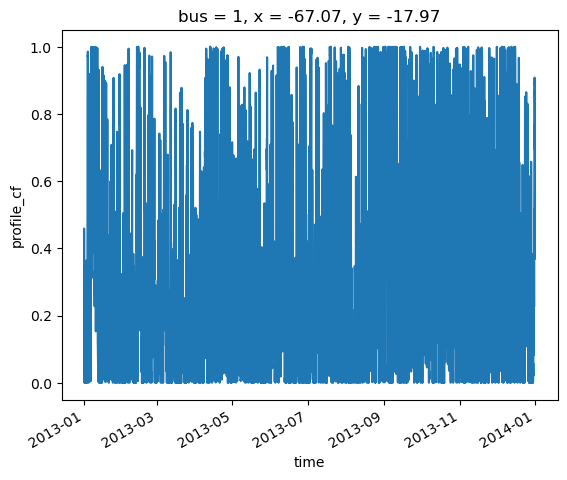

In [52]:
print(xr_new.profile_cf.min().item())
print(xr_new.profile_cf.max().item())


xr_new.profile_cf.isel(bus=0).plot()#.mean()

In [53]:
xr_out["profile"] = xr_new["profile_cf"]
xr_out

<xarray.Dataset>
Dimensions:    (bus: 87, time: 8760)
Coordinates:
  * bus        (bus) object '1' '100' '101' '102' '103' ... '94' '95' '96' '97'
    x          (bus) float64 -67.07 -63.26 -63.16 -65.75 ... -66.0 -66.93 -63.56
    y          (bus) float64 -17.97 -17.31 -17.65 ... -20.34 -18.21 -21.69
  * time       (time) datetime64[ns] 2013-01-01 ... 2013-12-31T23:00:00
Data variables:
    profile    (time, bus) float64 0.003785 0.9078 0.9845 ... 0.2178 0.0003488
    p_nom_max  (bus) float64 1.515e+03 1.808e+03 742.2 ... 454.7 2.171e+03
    CAPEX      (bus) float64 98.57 121.0 84.54 144.2 ... 151.6 164.2 92.48 159.5

(array([ 2.,  6.,  2.,  7.,  4.,  7.,  7., 11.,  4.,  7.,  3.,  6.,  3.,
         1.,  0.,  1.,  1.,  2.,  0.,  2.,  0.,  1.,  2.,  1.,  1.,  0.,
         2.,  3.,  0.,  1.]),
 array([0.19201162, 0.20481727, 0.21762291, 0.23042856, 0.2432342 ,
        0.25603985, 0.26884549, 0.28165114, 0.29445678, 0.30726243,
        0.32006807, 0.33287372, 0.34567936, 0.35848501, 0.37129065,
        0.38409629, 0.39690194, 0.40970758, 0.42251323, 0.43531887,
        0.44812452, 0.46093016, 0.47373581, 0.48654145, 0.4993471 ,
        0.51215274, 0.52495839, 0.53776403, 0.55056968, 0.56337532,
        0.57618097]),
 <BarContainer object of 30 artists>)

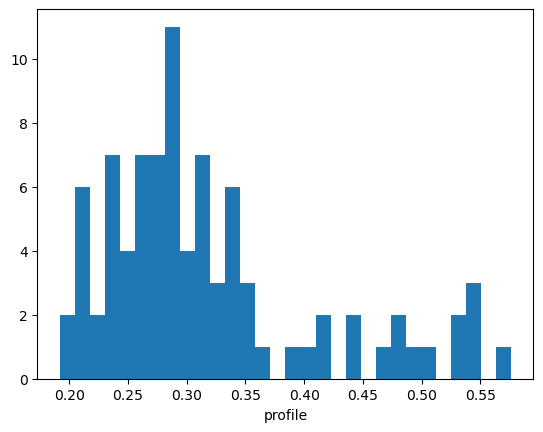

In [54]:
mean_cf = xr_out["profile"].mean("time")

mean_cf.plot.hist(bins=30)

C:\Users\Carlos\AppData\Local\Temp\ipykernel_13352\4180993161.py:5: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


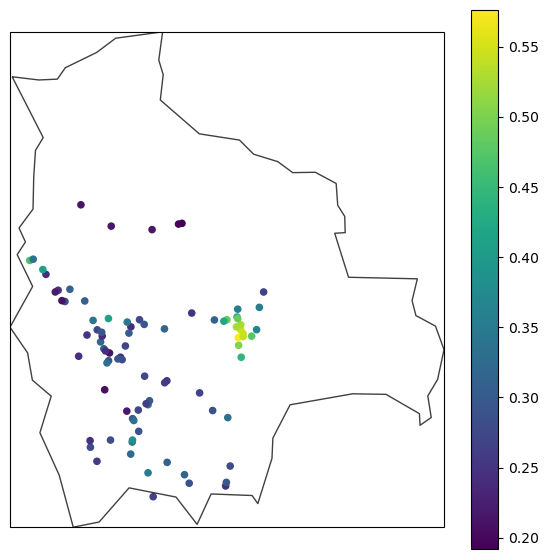

In [55]:
#create shared figure
fig, ax = plt.subplots(figsize=(7, 7),subplot_kw={'projection': ccrs.PlateCarree()})

#determine the limits of the country
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
shapes=world[world.name.isin(["Bolivia"])].set_index("name")
shapes.boundary.plot(ax=ax, color="black", alpha=0.75, linewidth=1,)

#Check values
mean_cf = xr_out["profile"].mean("time")

df = mean_cf.to_dataframe(name="mean_cf").reset_index()

df["x"] = xr_out["x"].reindex(bus=df["bus"]).values
df["y"] = xr_out["y"].reindex(bus=df["bus"]).values

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.x, df.y),
    crs="EPSG:4326"
)

#plot
gdf.plot(ax=ax, column="mean_cf", cmap="viridis", legend=True, markersize=20,
    transform=ccrs.PlateCarree())

minx, miny, maxx, maxy = shapes.total_bounds
ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())

C:\Users\Carlos\AppData\Local\Temp\ipykernel_13352\3773322985.py:5: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


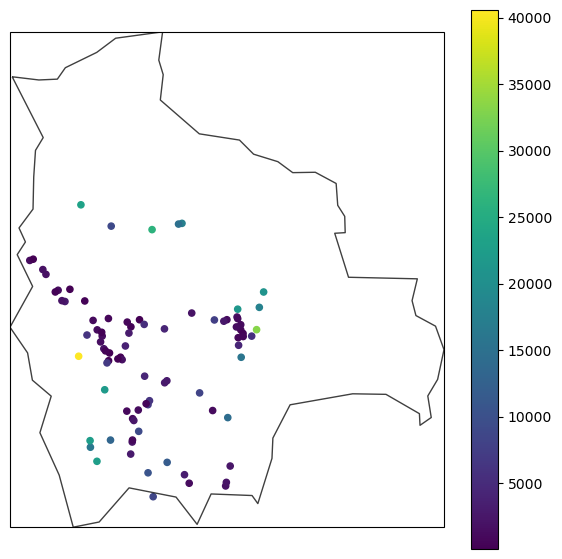

In [56]:
#create shared figure
fig, ax = plt.subplots(figsize=(7, 7),subplot_kw={'projection': ccrs.PlateCarree()})

#determine the limits of the country
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
shapes=world[world.name.isin(["Bolivia"])].set_index("name")
shapes.boundary.plot(ax=ax, color="black", alpha=0.75, linewidth=1,)

#Check values
mean_pmax = xr_out["p_nom_max"]

df2 = mean_pmax.to_dataframe(name="p_max").reset_index()

df2["x"] = xr_out["x"].reindex(bus=df2["bus"]).values
df2["y"] = xr_out["y"].reindex(bus=df2["bus"]).values

gdf2 = gpd.GeoDataFrame(
    df2,
    geometry=gpd.points_from_xy(df2.x, df2.y),
    crs="EPSG:4326"
)

#plot
gdf2.plot(ax=ax, column="p_max", cmap="viridis", legend=True, markersize=20,
    transform=ccrs.PlateCarree())

minx, miny, maxx, maxy = shapes.total_bounds
ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())

In [57]:
print(resources)

print(xr_out)


<xarray.Dataset>
Dimensions:           (time: 8760, bus: 122, y: 46, x: 43)
Coordinates:
  * time              (time) datetime64[ns] 2013-01-01 ... 2013-12-31T23:00:00
  * bus               (bus) <U3 '0' '1' '4' '6' '8' ... '162' '163' '164' '165'
  * y                 (y) float64 -23.1 -22.8 -22.5 -22.2 ... -10.2 -9.9 -9.6
  * x                 (x) float64 -69.9 -69.6 -69.3 -69.0 ... -57.9 -57.6 -57.3
Data variables:
    profile           (time, bus) float64 0.0 0.0 0.0 0.1551 ... 0.0 0.7487 0.0
    weight            (bus) float64 ...
    p_nom_max         (bus) float64 ...
    potential         (y, x) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    average_distance  (bus) float64 30.2 20.45 32.19 15.63 ... 53.37 16.8 40.82
<xarray.Dataset>
Dimensions:    (bus: 87, time: 8760)
Coordinates:
  * bus        (bus) object '1' '100' '101' '102' '103' ... '94' '95' '96' '97'
    x          (bus) float64 -67.07 -63.26 -63.16 -65.75 ... -66.0 -66.93 -63.56
    y          (bus) float64 

In [58]:
# buses in xr_out that are NOT in resources (should be empty)
set(xr_out.bus.values) - set(resources.bus.values)

set()

In [59]:
#ensure datatype consistency between both datasets
resources = resources.assign_coords(
    bus=resources.bus.astype(str)
)

xr_out = xr_out.assign_coords(
    bus=xr_out.bus.astype(str)
)

In [60]:
#overwrite the profiles from atlite with the ones from MSR
resources_new = resources.copy(deep=True)

resources_new["profile"].loc[
    dict(bus=xr_out.bus)
] = xr_out["profile"]

In [61]:
#overwrite the max capacity from atlite with the one from MSR
resources_new["p_nom_max"].loc[
    dict(bus=xr_out.bus)
] = xr_out["p_nom_max"]

#and store capex as a potential future input
if "CAPEX" not in resources_new:
    resources_new["CAPEX"] = xr.zeros_like(resources_new["p_nom_max"])

resources_new["CAPEX"].loc[
    dict(bus=xr_out.bus)
] = xr_out["CAPEX"]

In [62]:
#Set to 0 data for buses not considered in the MSR
non_msr_buses = sorted(
    set(resources_new.bus.values) - set(xr_out.bus.values)
)

resources_new["profile"].loc[
    dict(bus=non_msr_buses)
] = 0.0

resources_new["p_nom_max"].loc[
    dict(bus=non_msr_buses)
] = 0.0

In [63]:
#general checks to verify the the new dataset is similar to the initial pypsa-based one (resources)
# 1. Bus count unchanged
assert resources_new.dims["bus"] == 122
assert resources.dims["bus"] == 122

# 2. MSR buses correctly overwritten
b = xr_out.bus.values[0]

assert np.allclose(
    resources_new["profile"].sel(bus=b).values,
    xr_out["profile"].sel(bus=b).values,
    rtol=1e-6,
    atol=1e-8,
)

# 3. Availability factors still valid
assert resources_new.profile.min() >= 0
assert resources_new.profile.max() <= 1

In [64]:
resources_new.to_netcdf("Cost-Supply\profile_onwind_new.nc")

In [65]:
resources_new

<xarray.Dataset>
Dimensions:           (time: 8760, bus: 122, y: 46, x: 43)
Coordinates:
  * time              (time) datetime64[ns] 2013-01-01 ... 2013-12-31T23:00:00
  * y                 (y) float64 -23.1 -22.8 -22.5 -22.2 ... -10.2 -9.9 -9.6
  * x                 (x) float64 -69.9 -69.6 -69.3 -69.0 ... -57.9 -57.6 -57.3
  * bus               (bus) <U3 '0' '1' '4' '6' '8' ... '162' '163' '164' '165'
Data variables:
    profile           (time, bus) float64 0.0 0.003785 0.3981 ... 0.249 0.0 0.0
    weight            (bus) float64 ...
    p_nom_max         (bus) float64 0.0 1.515e+03 562.8 ... 4.178e+03 0.0 0.0
    potential         (y, x) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    average_distance  (bus) float64 30.2 20.45 32.19 15.63 ... 53.37 16.8 40.82
    CAPEX             (bus) float64 0.0 98.57 130.0 101.5 ... 116.8 0.0 0.0